In [3]:
# we need to run on a py file instead of a jupyter notebook otherwise multiprocessing will not work properly
import os
import sys

# agent.py / monte_carlo_tree_search.py / minimax.py import `Team2.data_processing`,
# so the repo root (the parent of Team2/) has to be on sys.path. This notebook lives in
# Team2/, so sys.path already covers `agent` and `model_files` themselves.
TEAM2_DIR = os.path.abspath("")
REPO_ROOT = os.path.dirname(TEAM2_DIR)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from agent import Agent, pit
from model_files.SLPolicyValueGPU import SLPolicyValueNetwork
import torch
import chess


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device:", device)

WEIGHTS_PATH = os.path.join(TEAM2_DIR, "model_weights", "lab_trained_epoch_1.pth")

model1 = SLPolicyValueNetwork().to(device)
checkpoint = torch.load(WEIGHTS_PATH, map_location=device)
model1.load_state_dict(checkpoint["model"])
model1.eval()

agent = Agent(policy_value_network=model1, c_puct=1.0, dirichlet_alpha=0.3, dirichlet_epsilon=0.0)
# epsilon is set to 0 for no noise

mcts_policy_temp = 1.0 #setting temp to 1 means no temperature (temperature for policy)
mcts_temp = 1.0 # <1 means we boost the uct scores of top moves
sims = 1000


def show_top_moves(board, top_n=5, num_simulations=None, temperature=0.0, debug=True):
    """Run the agent on `board` and print its top `top_n` candidate moves."""
    best, combined = agent.select_move(
        game_state=board,
        num_simulations=sims if num_simulations is None else num_simulations,
        temperature=temperature,
        debug=debug,
        mcts_policy_temperature=mcts_policy_temp,
        mcts_temperature=mcts_temp,
    )

    def label(uci):
        try:
            return f"{board.san(chess.Move.from_uci(uci))} ({uci})"
        except Exception:
            return uci

    side = "white" if board.turn == chess.WHITE else "black"
    total = sum(visits for _, visits, _, _ in combined) or 1

    print(f"{side} to move | best: {label(best)} | static eval: {agent.evaluate_value(board.fen()):+.3f}")
    print(f"{'#':>2}  {'move':<16}{'visits':>8}{'share':>8}{'eval':>9}{'prior':>9}")
    print("-" * 54)
    for rank, (uci, visits, ev, prior) in enumerate(combined[:top_n], start=1):
        print(f"{rank:>2}  {label(uci):<16}{int(visits):>8}{visits / total:>8.1%}{ev:>+9.3f}{prior:>9.4f}")
    if not combined:
        print("   (no visit counts -- was debug=True?)")


using device: cpu


black to move | best: d5 (d7d5) | static eval: -0.091
 #  move              visits   share     eval    prior
------------------------------------------------------
 1  d5 (d7d5)            474   47.4%   -0.057   0.3779
 2  Nf6 (g8f6)           361   36.1%   -0.065   0.3775
 3  e6 (e7e6)             77    7.7%   -0.074   0.0957
 4  d6 (d7d6)             45    4.5%   -0.072   0.0583
 5  g6 (g7g6)             20    2.0%   -0.109   0.0481


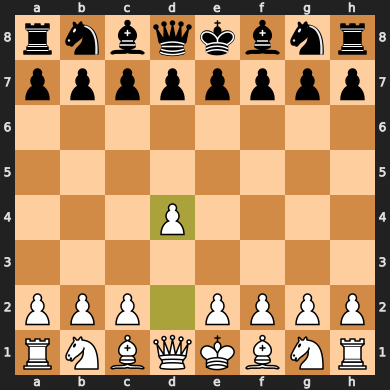

In [4]:
# Test evaluations

# should be about equal
board = chess.Board()
board.push_uci("d2d4")
show_top_moves(board)
board

white to move | best: Kb2 (a1b2) | static eval: +0.976
 #  move              visits   share     eval    prior
------------------------------------------------------
 1  Kb2 (a1b2)           240   24.0%   +0.938   0.1094
 2  Kb1 (a1b1)           237   23.7%   +0.937   0.1137
 3  Qd8+ (d3d8)           72    7.2%   +0.866   0.1824
 4  Ka2 (a1a2)            64    6.4%   +0.939   0.0226
 5  Qc4+ (d3c4)           47    4.7%   +0.867   0.1164


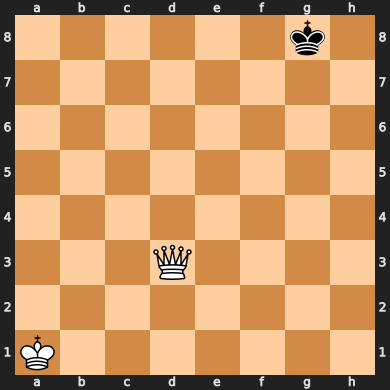

In [5]:
board = chess.Board("6k1/8/8/8/8/3Q4/8/K7 w - - 0 1")
show_top_moves(board)
board

black to move | best: Kf8 (g8f8) | static eval: -0.967
 #  move              visits   share     eval    prior
------------------------------------------------------
 1  Kf8 (g8f8)           356   35.6%   -0.877   0.1156
 2  Kf7 (g8f7)           319   31.9%   -0.904   0.3417
 3  Kg7 (g8g7)           318   31.8%   -0.922   0.5221
 4  Kh8 (g8h8)             6    0.6%   -0.964   0.0206


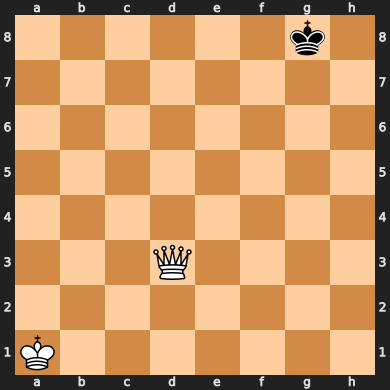

In [6]:
# should be negative (losing)
board = chess.Board("6k1/8/8/8/8/3Q4/8/K7 b - - 0 1")
show_top_moves(board)
board

white to move | best: Nxd5 (c3d5) | static eval: +0.095
 #  move              visits   share     eval    prior
------------------------------------------------------
 1  Nxd5 (c3d5)          772   77.3%   +0.252   0.0474
 2  Nf3 (g1f3)           150   15.0%   +0.093   0.7591
 3  d4 (d2d4)             44    4.4%   +0.165   0.1183
 4  Qf3 (d1f3)             4    0.4%   +0.110   0.0212
 5  d3 (d2d3)              2    0.2%   +0.093   0.0109


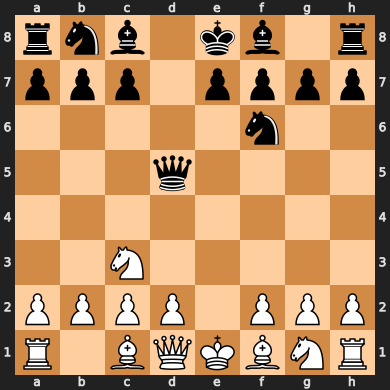

In [7]:
# should be positive (c3d5, somewhat winning)
board = chess.Board("rnb1kb1r/ppp1pppp/5n2/3q4/8/2N5/PPPP1PPP/R1BQKBNR w KQkq - 2 4")
show_top_moves(board)
board

black to move | best: Qxd4 (d8d4) | static eval: -0.065
 #  move              visits   share     eval    prior
------------------------------------------------------
 1  Qxd4 (d8d4)          959   96.0%   +0.367   0.7258
 2  Nc6 (b8c6)            11    1.1%   -0.023   0.1469
 3  Rg8 (h8g8)             1    0.1%   -0.037   0.0000
 4  Qd7 (d8d7)             1    0.1%   -0.017   0.0016
 5  Qd6 (d8d6)             1    0.1%   -0.027   0.0094


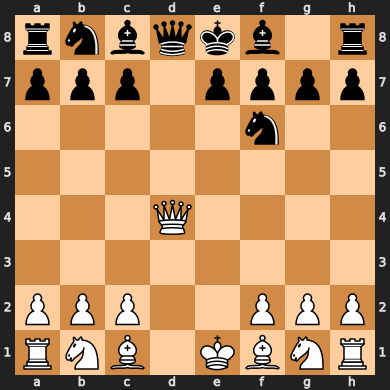

In [8]:
# should be positive (d8d4, somewhat winning)
board = chess.Board("rnbqkb1r/ppp1pppp/5n2/8/3Q4/8/PPP2PPP/RNB1KBNR b KQkq - 2 4")
show_top_moves(board)
board

white to move | best: Nf3 (g1f3) | static eval: -0.240
 #  move              visits   share     eval    prior
------------------------------------------------------
 1  Nf3 (g1f3)           402   40.2%   -0.375   0.6750
 2  Ne2 (g1e2)           171   17.1%   -0.334   0.0260
 3  Nc3 (b1c3)           141   14.1%   -0.358   0.1321
 4  c3 (c2c3)            112   11.2%   -0.338   0.0187
 5  Be3 (c1e3)            76    7.6%   -0.334   0.0109


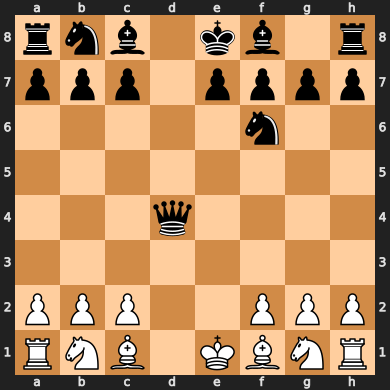

In [9]:
# should be negative (after d8d4, somewhat losing)
board = chess.Board("rnb1kb1r/ppp1pppp/5n2/8/3q4/8/PPP2PPP/RNB1KBNR w KQkq - 0 5")
show_top_moves(board)
board

white to move | best: Rxe7 (e6e7) | static eval: +0.048
 #  move              visits   share     eval    prior
------------------------------------------------------
 1  Rxe7 (e6e7)          951   95.2%   +0.416   0.7113
 2  Rxf6 (e6f6)            7    0.7%   -0.315   0.1866
 3  Qxf6+ (h6f6)           5    0.5%   -0.200   0.0658
 4  Qf8+ (h6f8)            1    0.1%   -0.181   0.0000
 5  Qxh7+ (h6h7)           1    0.1%   -0.771   0.0036


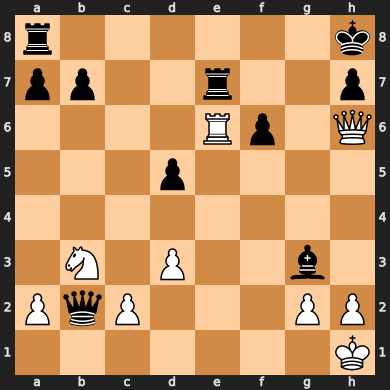

In [10]:
# should be positive (e6e7, somewhat winning)
board = chess.Board("r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2b1/PqP3PP/7K w - - 0 25")
show_top_moves(board)
board

black to move | best: Bc6 (d7c6) | static eval: -0.858
 #  move              visits   share     eval    prior
------------------------------------------------------
 1  Bc6 (d7c6)           232   23.2%   -0.611   0.1496
 2  Be6 (d7e6)           195   19.5%   -0.600   0.0469
 3  Be8 (d7e8)           143   14.3%   -0.595   0.0109
 4  Rc8 (d8c8)           101   10.1%   -0.649   0.1836
 5  Bg4 (d7g4)            96    9.6%   -0.612   0.0648


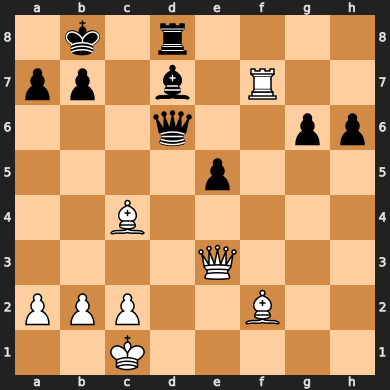

In [11]:
# should be positive (d6d1, mate in 3)
board = chess.Board("1k1r4/pp1b1R2/3q2pp/4p3/2B5/4Q3/PPP2B2/2K5 b - - 0 1")
show_top_moves(board)
board

black to move | best: Bg4+ (d7g4) | static eval: -0.967
 #  move              visits   share     eval    prior
------------------------------------------------------
 1  Bg4+ (d7g4)          973   97.4%   +0.875   0.6705
 2  Bc6+ (d7c6)            4    0.4%   -0.972   0.1516
 3  Rh8 (d8h8)             1    0.1%   -0.999   0.0000
 4  Rg8 (d8g8)             1    0.1%   -0.999   0.0001
 5  Rf8 (d8f8)             1    0.1%   -0.998   0.0001


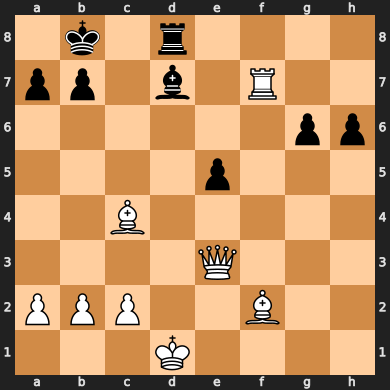

In [12]:
# should be positive (d7g4, mate in 2)
board = chess.Board("1k1r4/pp1b1R2/6pp/4p3/2B5/4Q3/PPP2B2/3K4 b - - 0 2")
show_top_moves(board)
board

white to move | best: Kc1 (d1c1) | static eval: +0.916
 #  move              visits   share     eval    prior
------------------------------------------------------
 1  Kc1 (d1c1)           590   59.1%   -0.899   0.9341
 2  Ke1 (d1e1)           409   40.9%   -0.854   0.0659


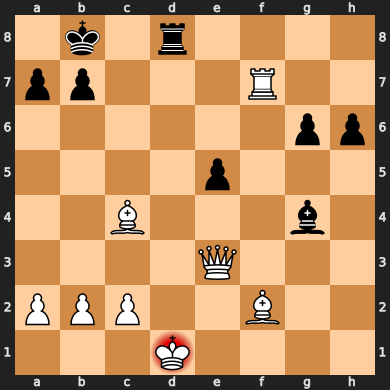

In [13]:
# should be negative (d7g4, mate in 1 coming)
board = chess.Board("1k1r4/pp3R2/6pp/4p3/2B3b1/4Q3/PPP2B2/3K4 w - - 1 3")
show_top_moves(board)
board

black to move | best: Rd1# (d8d1) | static eval: -0.959
 #  move              visits   share     eval    prior
------------------------------------------------------
 1  Rd1# (d8d1)          970   97.1%   +1.000   0.9933
 2  Rh8 (d8h8)             1    0.1%   -0.999   0.0000
 3  Rg8 (d8g8)             1    0.1%   -1.000   0.0000
 4  Rf8 (d8f8)             1    0.1%   -0.999   0.0000
 5  Re8 (d8e8)             1    0.1%   -0.999   0.0002


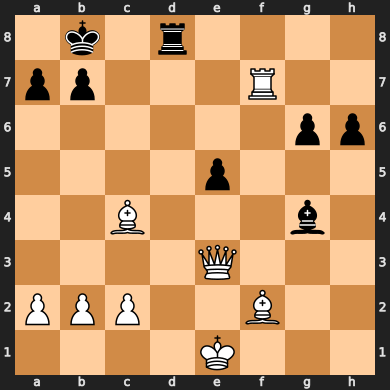

In [14]:
# should be positive (d8d1, mate in 1)
board = chess.Board("1k1r4/pp3R2/6pp/4p3/2B3b1/4Q3/PPP2B2/4K3 b - - 2 3")
show_top_moves(board)
board

black to move | best: Nd5 (f6d5) | static eval: -0.073
 #  move              visits   share     eval    prior
------------------------------------------------------
 1  Nd5 (f6d5)           454   45.4%   -0.097   0.5900
 2  a6 (a7a6)            233   23.3%   -0.057   0.0025
 3  Ng4 (f6g4)           187   18.7%   -0.106   0.2981
 4  Qc7 (d8c7)            53    5.3%   -0.066   0.0135
 5  Ne4 (f6e4)            41    4.1%   -0.111   0.0714


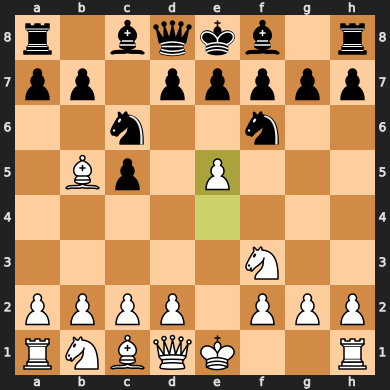

In [15]:
#why does it take on e5??
board = chess.Board()
board.push_uci("e2e4")
board.push_uci("c7c5")
board.push_uci("g1f3")
board.push_uci("b8c6")
board.push_uci("f1b5")
board.push_uci("g8f6")
board.push_uci("e4e5")
show_top_moves(board)
board


white to move | best: O-O (e1g1) | static eval: +0.084
 #  move              visits   share     eval    prior
------------------------------------------------------
 1  O-O (e1g1)           684   68.5%   +0.104   0.6617
 2  Nc3 (b1c3)           218   21.8%   +0.099   0.2436
 3  d4 (d2d4)             42    4.2%   +0.106   0.0383
 4  c4 (c2c4)             22    2.2%   +0.088   0.0334
 5  c3 (c2c3)              4    0.4%   +0.066   0.0097


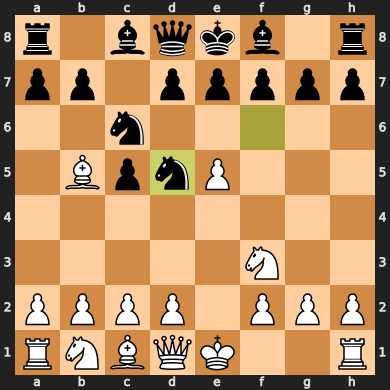

In [16]:
# clearly worse for black?
board = chess.Board()
board.push_uci("e2e4")
board.push_uci("c7c5")
board.push_uci("g1f3")
board.push_uci("b8c6")
board.push_uci("f1b5")
board.push_uci("g8f6")
board.push_uci("e4e5")
board.push_uci("f6d5")
show_top_moves(board)
board


black to move | best: Nc7 (d5c7) | static eval: -0.098
 #  move              visits   share     eval    prior
------------------------------------------------------
 1  Nc7 (d5c7)           638   63.9%   -0.081   0.6550
 2  Nf4 (d5f4)           189   18.9%   -0.079   0.1816
 3  Ndb4 (d5b4)           84    8.4%   -0.064   0.0422
 4  Nb6 (d5b6)            62    6.2%   -0.104   0.1092
 5  e6 (e7e6)              3    0.3%   -0.101   0.0058


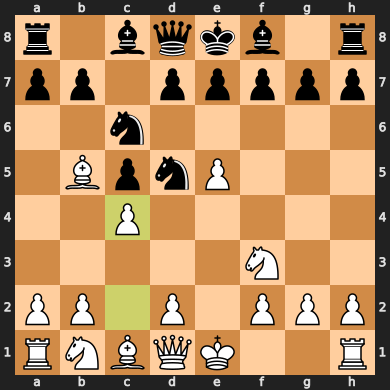

In [17]:
# clearly worse for black?
board = chess.Board()
board.push_uci("e2e4")
board.push_uci("c7c5")
board.push_uci("g1f3")
board.push_uci("b8c6")
board.push_uci("f1b5")
board.push_uci("g8f6")
board.push_uci("e4e5")
board.push_uci("f6d5")
board.push_uci("c2c4")
show_top_moves(board)
board


white to move | best: O-O (e1g1) | static eval: -0.006
 #  move              visits   share     eval    prior
------------------------------------------------------
 1  O-O (e1g1)           464   46.4%   +0.074   0.4829
 2  Nc3 (b1c3)           366   36.6%   +0.084   0.2620
 3  a3 (a2a3)             69    6.9%   +0.040   0.1469
 4  d4 (d2d4)             53    5.3%   +0.071   0.0566
 5  Bxc6 (b5c6)           16    1.6%   +0.062   0.0218


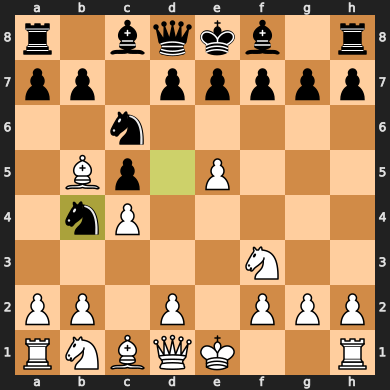

In [18]:
board = chess.Board()
board.push_uci("e2e4")
board.push_uci("c7c5")
board.push_uci("g1f3")
board.push_uci("b8c6")
board.push_uci("f1b5")
board.push_uci("g8f6")
board.push_uci("e4e5")
board.push_uci("f6d5")
board.push_uci("c2c4")
board.push_uci("d5b4")
show_top_moves(board)
board


white to move | best: Bxf3 (e2f3) | static eval: -0.229
 #  move              visits   share     eval    prior
------------------------------------------------------
 1  Bxf3 (e2f3)          739   74.0%   -0.126   0.2879
 2  Qxf3 (b3f3)           72    7.2%   -0.241   0.0071
 3  dxe7 (d6e7)           66    6.6%   -0.291   0.1525
 4  g3 (g2g3)             66    6.6%   -0.371   0.4036
 5  Bc4 (e2c4)             6    0.6%   -0.398   0.0450


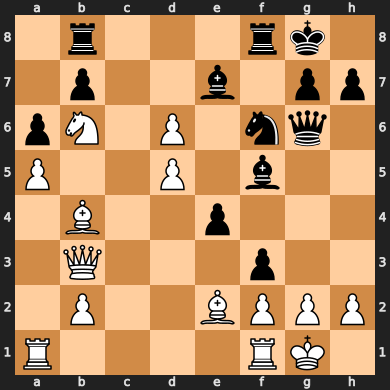

In [19]:
board = chess.Board("1r3rk1/1p2b1pp/pN1P1nq1/P2P1b2/1B2p3/1Q3p2/1P2BPPP/R4RK1 w - - 1 22")
show_top_moves(board)
board

white to move | best: Qg3 (f3g3) | static eval: +0.025
 #  move              visits   share     eval    prior
------------------------------------------------------
 1  Qg3 (f3g3)           744   74.5%   +0.064   0.4378
 2  Qh3 (f3h3)            76    7.6%   -0.037   0.0621
 3  dxe7 (d6e7)           64    6.4%   -0.110   0.2674
 4  Qxe4 (f3e4)           56    5.6%   -0.030   0.0039
 5  Qe2 (f3e2)             8    0.8%   -0.241   0.0847


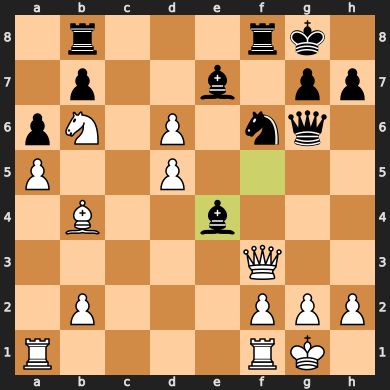

In [20]:
board = chess.Board("1r3rk1/1p2b1pp/pN1P1nq1/P2P1b2/1B2p3/1Q3p2/1P2BPPP/R4RK1 w - - 1 22")
board.push_uci("e2f3")
board.push_uci("e4f3")
board.push_uci("b3f3")
board.push_uci("f5e4")
show_top_moves(board)
board

black to move | best: Bxf3 (e4f3) | static eval: +0.419
 #  move              visits   share     eval    prior
------------------------------------------------------
 1  Bxf3 (e4f3)          856   85.7%   +0.912   0.5422
 2  Bxd6 (e7d6)           60    6.0%   +0.569   0.1958
 3  Bd8 (e7d8)            52    5.2%   +0.597   0.0845
 4  Kh8 (g8h8)             1    0.1%   +0.097   0.0007
 5  Kf7 (g8f7)             1    0.1%   +0.042   0.0005


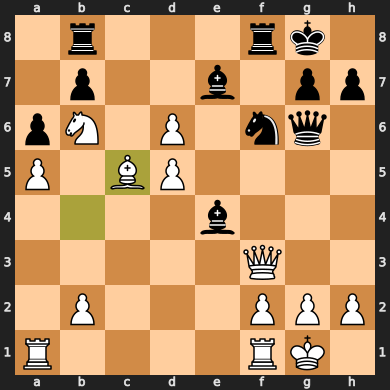

In [21]:
board = chess.Board("1r3rk1/1p2b1pp/pN1P1nq1/P2P1b2/1B2p3/1Q3p2/1P2BPPP/R4RK1 w - - 1 22")
board.push_uci("e2f3")
board.push_uci("e4f3")
board.push_uci("b3f3")
board.push_uci("f5e4")
board.push_uci("b4c5")
show_top_moves(board)
board

white to move | best: dxe7 (d6e7) | static eval: -0.705
 #  move              visits   share     eval    prior
------------------------------------------------------
 1  dxe7 (d6e7)          691   69.2%   -0.930   0.9890
 2  Nd7 (b6d7)           245   24.5%   -0.886   0.0000
 3  d7 (d6d7)             37    3.7%   -0.628   0.0054
 4  Nc8 (b6c8)             1    0.1%   -0.935   0.0000
 5  Na8 (b6a8)             1    0.1%   -0.958   0.0000


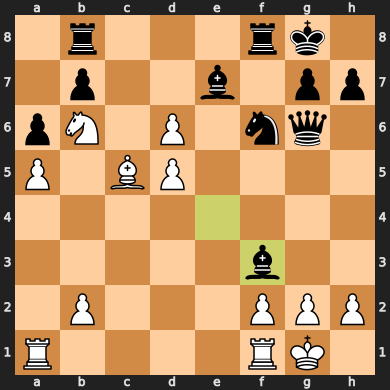

In [22]:
board = chess.Board("1r3rk1/1p2b1pp/pN1P1nq1/P2P1b2/1B2p3/1Q3p2/1P2BPPP/R4RK1 w - - 1 22")
board.push_uci("e2f3")
board.push_uci("e4f3")
board.push_uci("b3f3")
board.push_uci("f5e4")
board.push_uci("b4c5")
board.push_uci("e4f3")
show_top_moves(board)
board

black to move | best: Qxg2# (g6g2) | static eval: +0.943
 #  move              visits   share     eval    prior
------------------------------------------------------
 1  Qxg2# (g6g2)         771   77.2%   +1.000   0.1676
 2  Bxd6 (e7d6)           55    5.5%   +0.817   0.3303
 3  Bd8 (e7d8)            42    4.2%   +0.944   0.0826
 4  Bxg2 (f3g2)           41    4.1%   +0.913   0.1023
 5  Nxd5 (f6d5)           25    2.5%   +0.921   0.0686


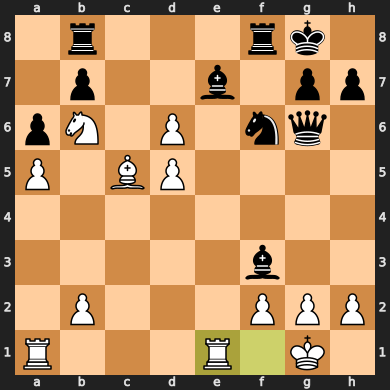

In [23]:
board = chess.Board("1r3rk1/1p2b1pp/pN1P1nq1/P2P1b2/1B2p3/1Q3p2/1P2BPPP/R4RK1 w - - 1 22")
board.push_uci("e2f3")
board.push_uci("e4f3")
board.push_uci("b3f3")
board.push_uci("f5e4")
board.push_uci("b4c5")
board.push_uci("e4f3")
board.push_uci("f1e1")
show_top_moves(board)
board